In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# reading the dataset
words = open('names.txt', 'r').read().splitlines()
words[:5], len(words)

(['emma', 'olivia', 'ava', 'isabella', 'sophia'], 32033)

In [3]:
# building the vocabulary of characters and mappings
chars = sorted(set(''.join(words)))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}
vocab_size = len(itos) # since our vocabulary is just the characters

In [4]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
    return X, Y


import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((block_size * n_embd, 200),    generator=g)
b1 = torch.randn(n_hidden,                      generator=g)
W2 = torch.randn((n_hidden, vocab_size),        generator=g)
b2 = torch.randn(vocab_size,                    generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [6]:
sum(p.nelement() for p in parameters)

11897

In [7]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the two vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre activation
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weight updates
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    

      0/ 200000: 27.8817
  10000/ 200000: 2.8138
  20000/ 200000: 2.5218
  30000/ 200000: 2.7874
  40000/ 200000: 2.0334
  50000/ 200000: 2.6237
  60000/ 200000: 2.3289
  70000/ 200000: 2.0826
  80000/ 200000: 2.2784
  90000/ 200000: 2.2252
 100000/ 200000: 2.0428
 110000/ 200000: 2.3121
 120000/ 200000: 2.0570
 130000/ 200000: 2.4546
 140000/ 200000: 2.2233
 150000/ 200000: 2.1551
 160000/ 200000: 2.0597
 170000/ 200000: 1.7981
 180000/ 200000: 2.0194
 190000/ 200000: 1.7459


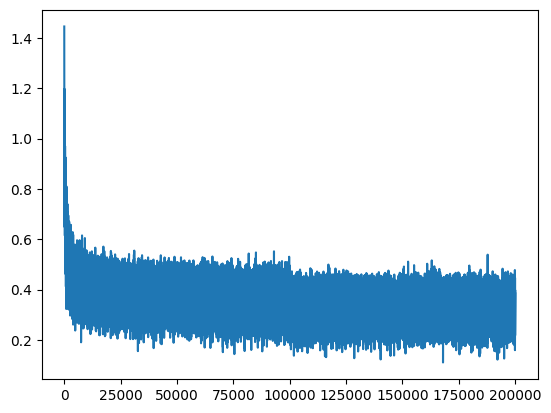

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 2.1267659664154053
val 2.1697638034820557


In [12]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(emb.shape[0], -1)
        h = torch.tanh(embcat @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, 1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    
    print(''.join(out))
        

carlah.
amorie.
khirmin.
rey.
cassanden.
jazhubedah.
sart.
kaeli.
nellara.
chaiir.


we can see that the loss in the first iteration is very high.\
reason for that is our neural network is not initialized correctly\
what should be our baseline model initialization? => every character is equally like to come next.\
so basically, probability of every character to come next should (1/27.0) in our case.\
So, our model should be initialized to kind of have this configurations.

In [ ]:
# so if probability of each character would be 1/27, we can find the loss for that
-torch.tensor(1/27.0).log()
# tensor(3.2958)

# so this is the base loss we can expect
# but how do we initialize in the network

tensor(3.2958)

In [ ]:
 # 4 dimensional example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4) * 100
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log() # considering the label is 2
logits, probs, loss

# in case of extreme values, loss would be too high. Randomly initializing weights has this problem
# so we want logits to be roughly zero or they should be equal so as we hit the base loss
# if numbers are equal, probs would still be the same, but we don't want to assign logits an arbitrary negative or positive value so just 0 is fine

(tensor([  4.1077,  67.5751,  11.2680, -56.3347]),
 tensor([2.7319e-28, 1.0000e+00, 3.5168e-25, 0.0000e+00]),
 tensor(56.3071))

In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((block_size * n_embd, 200),    generator=g) * (5/3)/((block_size * n_embd) ** 0.5)  #  <=this is Kaiming init #* 0.2
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0 # initialization to make logits zero
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [56]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the two vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre activation
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weight updates
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    

      0/ 200000: 3.3135
  10000/ 200000: 2.1648
  20000/ 200000: 2.3061
  30000/ 200000: 2.4541
  40000/ 200000: 1.9787
  50000/ 200000: 2.2930
  60000/ 200000: 2.4232
  70000/ 200000: 2.0680
  80000/ 200000: 2.3095
  90000/ 200000: 2.1207
 100000/ 200000: 1.8269
 110000/ 200000: 2.2045
 120000/ 200000: 1.9797
 130000/ 200000: 2.3946
 140000/ 200000: 2.1000
 150000/ 200000: 2.1948
 160000/ 200000: 1.8619
 170000/ 200000: 1.7809
 180000/ 200000: 1.9673
 190000/ 200000: 1.8295


In [ ]:
# so the loss after the first iteration is very high
# if we look at the logits here
print(logits[0])
# tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
    #       1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
    #      -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
    #      14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
    #    grad_fn=<SelectBackward0>)
    
# after the initialization, checking the logits
# tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
#          0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
#         -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
#         -0.2154,  0.0725,  0.1141], grad_fn=<SelectBackward0>)

# logits are coming much more symmetrical and not taking extreme values

tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
         0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
        -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
        -0.2154,  0.0725,  0.1141], grad_fn=<SelectBackward0>)


we see here that logits are taking very extreme values and hence the high loss\
so what can we do to make the logits roughly zero here\
since logits = h @ W2 + b2\
first thing that we can do is that we can make b2 zero at the initialization\
also we can make W2 zero too. But we won't do that as of now but we will make W2 a very small value\

so after the initialization, we can see that the initial loss is very low =>       0/ 200000: 3.3221
       

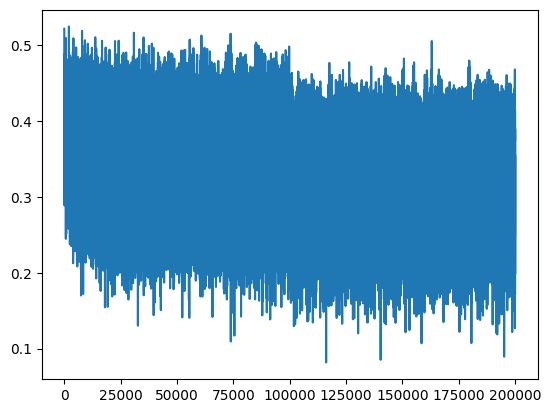

In [ ]:
plt.plot(lossi)

# we are not getting a hockey stick type of curve now as initialization is much better than before
# getting a good initialization matters as we are not wasting the first few iterations on just squashing down the weights
# we can start improving the neural network from the get go

In [ ]:
split_loss('train')
split_loss('val')

# after fixing the softmax
# train 2.0695888996124268
# val 2.131074905395508

# after fixing tanh saturation at init
# train 2.0355966091156006
# val 2.1026782989501953

# also train and val loss have also slightly improved

train 2.0355966091156006
val 2.1026782989501953


In [ ]:
print(h) # this is the h after just one iteration
# we can see that some of the values are taking 1 and -1. This is due to tanh squashing values between -1 and 1
# we can improve on this by checking the distribution of h
print(h.shape) # torch.Size([32, 200])
# there are 32 examples and each example has 200 activations in it

tensor([[ 0.8100, -0.8997, -0.9993,  ..., -0.9097, -1.0000,  1.0000],
        [-1.0000, -0.9571, -0.7145,  ...,  0.4898,  0.9090,  0.9937],
        [ 0.9983, -0.3340,  1.0000,  ...,  0.9443,  0.9905,  1.0000],
        ...,
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000],
        [-1.0000, -0.4385, -0.8882,  ..., -0.3316,  0.9995,  1.0000],
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000]],
       grad_fn=<TanhBackward0>)
torch.Size([32, 200])


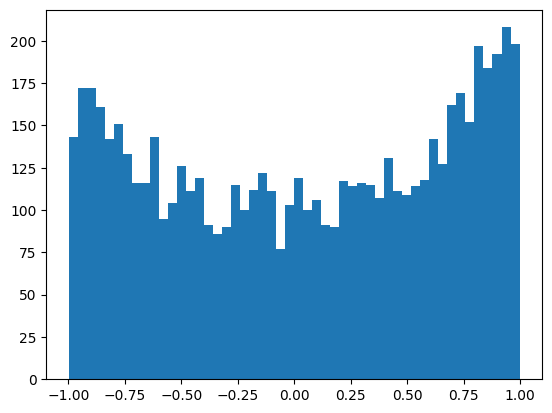

In [52]:
plt.hist((h.view(-1).tolist()), 50);

# we can see that most of the values are taking 1 and -1 here that tells us that our tanh is very active

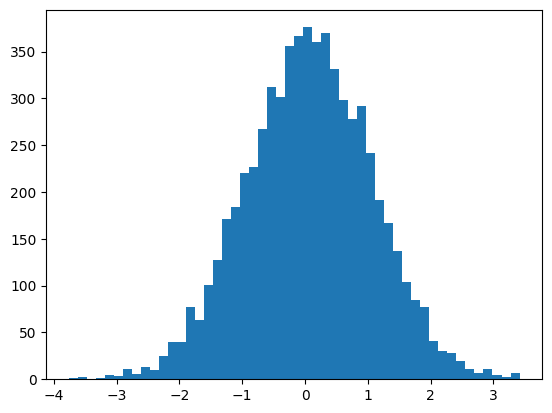

In [53]:
plt.hist((hpreact.view(-1).tolist()), 50);

# preactivation is pretty broad and taking a lot of values

So, what does this mean?\
if we check the backpropagation algorithm for tanh, derivative for a tanh neuron is (1 - t**2)
```
def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad # local derivative * global derivative
        out._backward = _backward
        return out
```
Basically, self.grad is becoming zero whenever x is 1 or -1. So, we are facing a problem of vanishing gradients here as most of the tanh values are 1 and -1\
And when t = 0, we are getting self.grad as out.grad. So, basically tanh neuron become inactive essentially and not changing the gradient at all

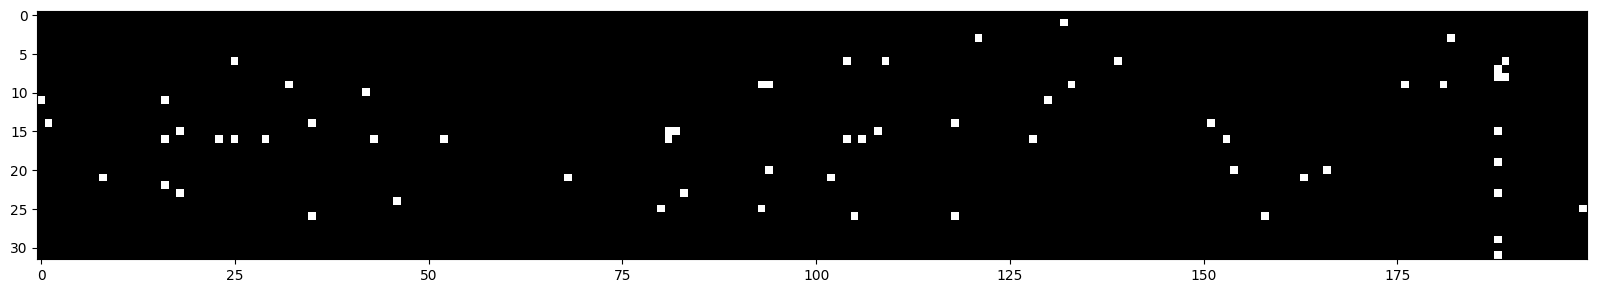

In [54]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # checking for the flat part or the extreme part of the tanh where the gradients are getting destroyed

there are 200 neurons in the tanh or hidden layer and there 32 examples.\
White part represents the h.abs() > 0.99 is true and black represents false\
We want to see if there is a dead neuron. For that we will check a complete column of whites but we cannot find any here\
Dead neuron is the when the neuron is not active even for one example so essentially it does not provide any value in the network.

Now what do we want to do after this?\
We want hpreact values to be near zero. From the plot above of hpreact, we can see that they are spread out. We don't want that\
To make hpreact near zero, we can initialize W1 and b1 as very small values\
After making the W1 and b1, we should see much less values of white in the imshow() => it is almost black that tells us that all the neurons got activated

When we are setting up scale numbers during the initialization, how do we come up with those numbers?

In [ ]:
# Example to demonstrate scaling the parameters
x = torch.randn(1000, 10)  # 1000 inputs each with a dimension of 10
w = torch.randn(10, 200) / 10 ** 0.5 # 200 neurons with 10 input size
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

# what we can see is that mean is same for both x and y i.e. both inputs and outputs but standard deviation expanded. Output became more spread out.
# mean is same is it is a symmetrical operation
# we don't want to change the standard deviation throughout the neural network and we want the keep the activations roughly the same.
# why?
# because irregular distribution makes the gradients too big or too small
# now if I multiply w with a big number like 20, the gaussian becomes more and more unstable as SD expands more
# and if I multiply w with a very small number like 0.2, gaussian becomes stable.
# now the question is what is the scaling factor?
# a thumb rule to scale the weights for any neural network is to divide it by the square root of number of inputs in that layer. This is also called fan_in
# so in above example, we will divide it by sqrt(10)
# Kaiming init => read pytorch documentation for this
# but for tanh, it is (5/3) / (sqrt(fan_in))
# so just multiply by the Kaiming init number

# although these initializations are not that important with the current architectures and the new innovations like batch normalization

tensor(-0.0045) tensor(1.0002)
tensor(-0.0043) tensor(3.1153)


# Batch normalization
why do we need batch normalization?\
From the examples above, we want our hidden layers values to be nearly Gaussian (normal distribution).\
The reason for this was that the extreme values in the preactivation layer are squashed to 1 or -1 which in turn becomes zero while calculating gradient of tanh during backprop and very small values (almost zero) makes the tanh inactive.\
Because of this we want the preactivation values to be roughly Gaussian.\
So, what batch normalization does it that it actually converts hidden layer values into Gaussian distribution.\
Now, how do we convert a distribution to a Gaussian distribution?\
xi = (xi - mean)/std

In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((block_size * n_embd, 200),    generator=g) * (5/3)/((block_size * n_embd) ** 0.5)  #  <=this is Kaiming init #* 0.2
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0 # initialization to make logits zero

bngain = torch.ones((1, n_hidden))  # batch normalization gain
bnbias = torch.zeros((1, n_hidden)) # batch normalization bias

bnmean_running = torch.zeros((1, n_hidden)) # setting this to 0s as during the initialization, bnbias is zero and bngain is 1, so basically running mean would be roughly 0 and std be roughly 1
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

In [80]:
# to makse sense of the broadcasting happening because of bngain and bnbias
print(hpreact.shape)
print(hpreact.mean(0, keepdim=True).shape)  # we want mean and std across the batch
print(hpreact.std(0, keepdim=True).shape)
print(((hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)).shape)
(bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)).shape

torch.Size([32, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([32, 200])


torch.Size([32, 200])

In [97]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the two vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre activation
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    
    with torch.no_grad():  # we don't need to find gradients for these variables as we are not using them for optimizing the network
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani  # sort of nudging it in the direction of the mean/std of the batch
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weight updates
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


Now, we did convert the preactivation values into the Gaussian distribution. But we kind of want that just during the initialization. As we want the backprop algorithm to set the tone of the distribution later. The distribution might shrink or might shift and we don't want to stop that by forcing the values to Gaussian distribution.\
In the batch normalization paper, to deal with this we are multiplying by gain and adding an offset.\
We will add them as the parameters of the neural network so that they also get trained.\
Basically, xi = bngain * ((xi - mean)/std) + bnbias

It is customary to take a linear layer or convolution layer and append a batch normalization layer to it to control the scale of activation at every point of neural network

In [ ]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

bnmean.shape, bnstd.shape

# since the during the inference time, we are just inputting one example to get a sensible result from that but the neural network expects a batch. So, after the training we calculate
# the mean and standard deviation and then use them during the inference time.
# But in the production and in pytorch what happens is that the network calculates these running mean and running std during the training time

(torch.Size([1, 200]), torch.Size([1, 200]))

In [98]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    # hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias  # calculated the running mean and running std during the training process
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 2.06659197807312
val 2.1050572395324707


In [ ]:
b1.grad
# we can see that b1's gradient are almost all zero. This is because they are getting subtracted out here hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
# this does not contribute anything to network so we can might as well remove it from the network for efficiency reasons.

tensor([ 4.6566e-10, -1.8626e-09,  8.7311e-10, -6.9849e-10, -4.6566e-10,
         1.8626e-09, -2.3283e-10, -2.3283e-09,  4.6566e-10, -2.7940e-09,
         1.3970e-09, -3.7253e-09,  1.8626e-09,  0.0000e+00,  4.6566e-10,
        -4.6566e-10,  6.9849e-10, -9.3132e-10, -1.1642e-09, -9.3132e-10,
        -1.1642e-09, -4.6566e-10,  2.9104e-11, -9.3132e-10, -1.1642e-09,
         4.6566e-10, -2.0955e-09,  0.0000e+00,  0.0000e+00, -3.4925e-10,
        -9.3132e-10, -3.0268e-09, -6.9849e-10,  1.5134e-09,  0.0000e+00,
        -1.3970e-09,  4.6566e-10,  1.8626e-09,  4.6566e-10, -1.8626e-09,
        -9.3132e-10,  5.8208e-10, -1.8626e-09, -2.3283e-10,  1.3970e-09,
         8.7311e-10, -9.8953e-10,  2.3283e-09,  9.3132e-10,  2.5611e-09,
         3.7253e-09,  9.3132e-10,  0.0000e+00,  2.3283e-09,  0.0000e+00,
        -4.6566e-10,  0.0000e+00, -2.3283e-10, -4.6566e-10, -4.6566e-10,
         4.6566e-10,  4.6566e-10,  2.3283e-10, -9.3132e-10,  4.6566e-10,
        -9.3132e-10,  1.3970e-09,  2.7940e-09,  0.0

In [ ]:
# after fixing the softmax
# train 2.0695888996124268
# val 2.131074905395508

# after fixing tanh saturation at init
# train 2.0355966091156006
# val 2.1026782989501953

# after adding a batch normalization layer
# train 2.0668270587921143
# val 2.104844808578491

Now, a very weird thing is happening in the batch normalization.\
Initially, we started off with one example, calculated the preactivations and logits of that example and then eventually loss.\
After that the batch or the mini-batch concept came. Essentially just for the efficiency purpose this was used.\
Now in batch normalization, for one example, logits or hpreact is a function of all the other examples in that batch due to mean and std.\
One would think that this is a bug, but as it turns out, it is not. Actually this works pretty well for the batch normalization.\
The reason why this thing makes sense is because when we are finding h and logits for one example, that value will jitter or fluctuate from batch to batch.\
That in turn will make the value of logits jitter. This jitter effect means that the numerical value of a particular example is not just the function of that particular example but also a function of the statistical composition of the batch it is in.\
This jittering effect actually works as a regularizer which inturn helps neural network so that it doesn't overfit.